## Executive Summary

This notebook presents an end-to-end evaluation of an A/B experiment under conflicting metrics. Using net revenue per user as the primary decision metric, the analysis concludes with a data-driven rollback recommendation.

## Hypothesis & Decision Criteria

**Primary Metric:** Net Revenue Per User (NRPU)

**H₀ (Null Hypothesis):** The new landing page does not increase NRPU.

**H₁ (Alternative Hypothesis):** The new landing page increases NRPU.

**Decision Rule:**
- Ship only if NRPU increases meaningfully and confidence intervals exclude material revenue loss.
- Conversion rate alone is insufficient to justify shipping.
- Confidence intervals are preferred over single point estimates to account for uncertainty.

## Business Problem

A new landing page was introduced to improve conversion. However, early signals showed metric conflicts. The objective is to determine whether the experiment should be shipped, partially rolled out, or rolled back.

## Dataset Overview

Each row represents a unique user session with experiment group assignment, conversion outcome, order value, user type, and support interaction.

In [1]:
import pandas as pd
import numpy as np 

In [2]:
df = pd.read_csv("ab_test_full_project_dataset.csv")

In [3]:
df.head()

,user_id,timestamp,group,landing_page,converted,order_value,user_type,support_ticket,ticket_category
0,851104,11:48.6,control,old_page,0,5.0,new,0,NaN
1,804228,01:45.2,control,old_page,0,5.0,new,0,NaN
2,661590,55:06.2,treatment,new_page,0,5.0,new,0,NaN
3,853541,28:03.1,treatment,new_page,0,5.0,returning,0,NaN
4,864975,52:26.2,control,old_page,1,134.9,returning,0,NaN


In [4]:
df.describe()

,user_id,converted,order_value,support_ticket
count,294480.000000,294480.000000,294480.000000,294480.000000
mean,787973.538896,0.119658,17.263495,0.058551
std,91210.917091,0.324562,34.875986,0.234782
min,630000.000000,0.000000,5.000000,0.000000
25%,709031.750000,0.000000,5.000000,0.000000
50%,787932.500000,0.000000,5.000000,0.000000
75%,866911.250000,0.000000,5.000000,0.000000
max,945999.000000,1.000000,238.270000,1.000000


## Exploratory Data Analysis (EDA)

Initial descriptive analysis to understand balance, conversion behavior, order value distribution, and support ticket pressure.

In [5]:
df.shape

(294480, 9)

In [6]:
df['group'].value_counts(normalize=True)

group
treatment    0.500129
control      0.499871
Name: proportion, dtype: float64

In [7]:
pd.crosstab(df['group'], df['landing_page'])

landing_page,new_page,old_page
group,,
control,1928,145274
treatment,145313,1965


In [8]:
df_clean = df[
    ((df.group == 'control') & (df.landing_page == 'old_page')) |
    ((df.group == 'treatment') & (df.landing_page == 'new_page'))
]

## Experiment Validity Checks

Ensure causal validity by removing contaminated observations where treatment exposure did not match assignment.

<Axes: title={'center': 'User Distribution by Experiment Group'}, xlabel='group'>

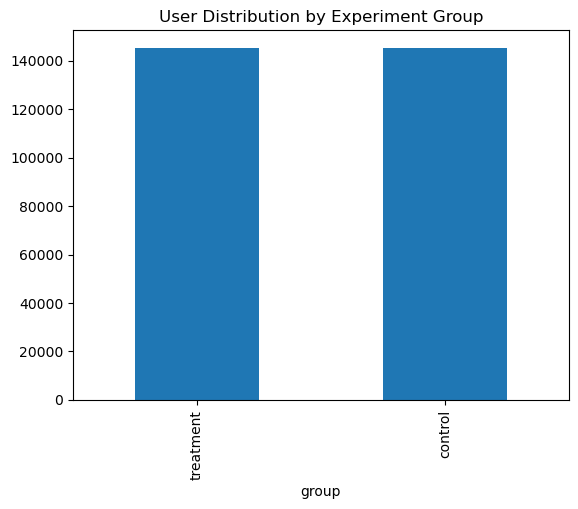

In [9]:
df_clean['group'].value_counts().plot(kind='bar', title='User Distribution by Experiment Group')

In [10]:
pd.crosstab(df_clean['group'], df_clean['landing_page'])

landing_page,new_page,old_page
group,,
control,0,145274
treatment,145313,0


In [11]:
conversion_rate = df_clean.groupby('group')['converted'].mean()
conversion_rate

group
control      0.120386
treatment    0.118806
Name: converted, dtype: float64

## Conversion Rate Analysis

Conversion rate acts as a behavioral gatekeeper but is insufficient alone.

In [12]:
conversion_lift = (
    conversion_rate['treatment'] - conversion_rate['control']
) / conversion_rate['control']
conversion_lift

np.float64(-0.013130162896435697)

Text(0.5, 1.0, 'Order Value Distribution by Experiment Group')

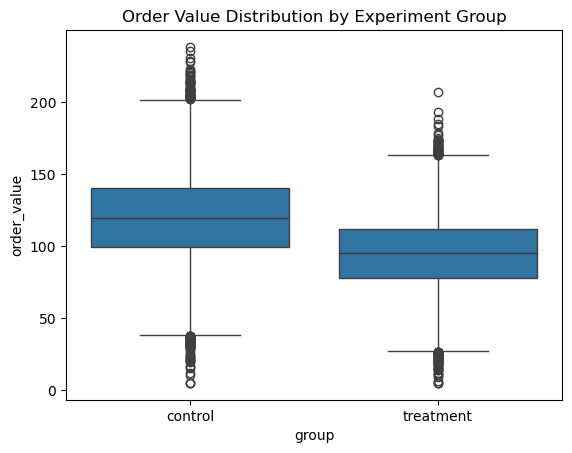

In [13]:
df_clean[df_clean.converted == 1].groupby('group')['order_value'].describe()
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    data=df_clean[df_clean.converted == 1],
    x='group',
    y='order_value'
)
plt.title('Order Value Distribution by Experiment Group')


## Average Order Value (AOV)

AOV measures transaction quality and revenue dilution risk.

In [14]:
aov = (df_clean[df_clean['converted']==1].groupby('group')['order_value'].mean())
aov

group
control      119.777797
treatment     95.059948
Name: order_value, dtype: float64

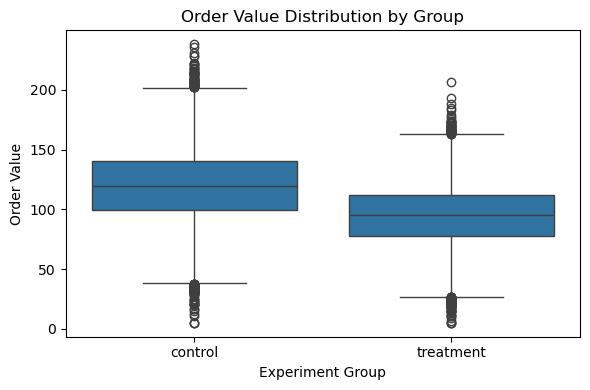

In [16]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.boxplot(
    data=df_clean[df_clean['converted'] == 1],
    x='group',
    y='order_value'
)

plt.title('Order Value Distribution by Group')
plt.xlabel('Experiment Group')
plt.ylabel('Order Value')

plt.tight_layout()
plt.show()


## Net Revenue Per User (Primary Metric)

NRPU combines conversion and order value into a single business-impact metric.

In [17]:
rpu = (df_clean.groupby('group')['order_value'].sum() / df_clean.groupby('group')['user_id'].count())
rpu

group
control      18.817675
treatment    15.699627
dtype: float64

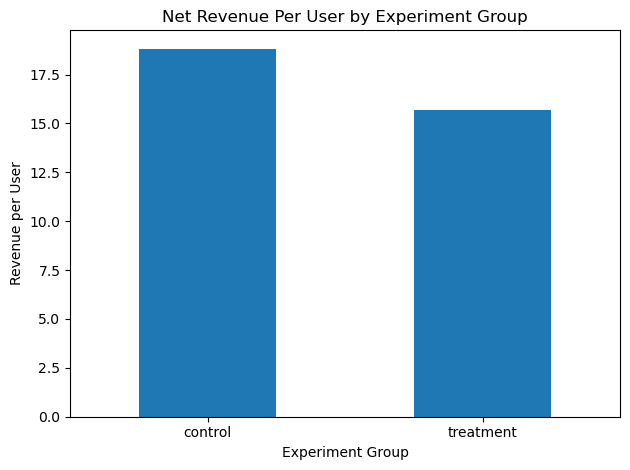

In [18]:
import matplotlib.pyplot as plt

rpu.plot(
    kind='bar',
    title='Net Revenue Per User by Experiment Group',
    ylabel='Revenue per User',
    xlabel='Experiment Group',
    rot=0
)

plt.tight_layout()
plt.show()


In [19]:
rpu_segment = (df_clean.groupby(['group' , 'user_type'])['order_value'].sum()/
                                 df_clean.groupby(['group','user_type'])['user_id'].count())
rpu_segment

group      user_type
control    new          18.729190
           returning    18.949083
treatment  new          15.718013
           returning    15.672000
dtype: float64

In [20]:
tickets_by_segment = (
    df_clean.groupby(['group', 'user_type'])['support_ticket'].mean() * 1000
)

tickets_by_segment


group      user_type
control    new          60.184759
           returning    18.936672
treatment  new          88.872079
           returning    50.134335
Name: support_ticket, dtype: float64

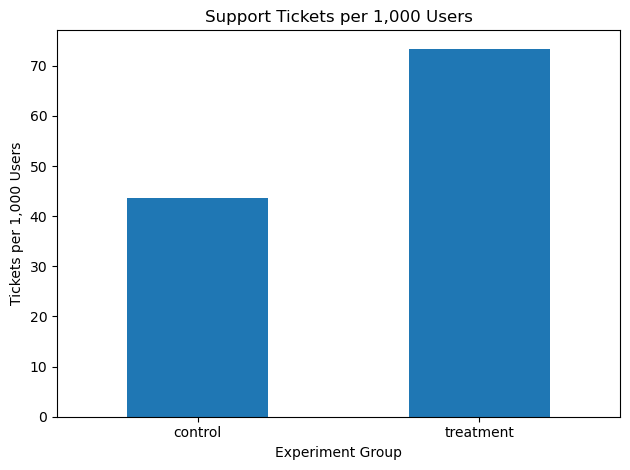

In [21]:
support_rate = df_clean.groupby('group')['support_ticket'].mean() * 1000

support_rate.plot(
    kind='bar',
    title='Support Tickets per 1,000 Users',
    ylabel='Tickets per 1,000 Users',
    xlabel='Experiment Group',
    rot=0
)

plt.tight_layout()
plt.show()


## Segmentation Analysis

Evaluate whether impacts differ between new and returning users.

In [22]:
control_revenue = df_clean[df_clean.group == 'control']['order_value'].values
treatment_revenue = df_clean[df_clean.group == 'treatment']['order_value'].values


In [ ]:
from scipy.stats import bootstrap
ci_control = bootstrap(
    (control_revenue,),
    np.mean,
    confidence_level=0.95,
    n_resamples=5000,
    method='percentile'
).confidence_interval

ci_treatment = bootstrap(
    (treatment_revenue,),
    np.mean,
    confidence_level=0.95,
    n_resamples=5000,
    method='percentile'
).confidence_interval

ci_control, ci_treatment


## Statistical Reliability & Confidence Intervals

Bootstrap confidence intervals are used to assess uncertainty in revenue estimates.

## Final Recommendation

**Decision:** Roll back the experiment.

The treatment resulted in a statistically and practically significant decline in net revenue per user and increased operational friction across all user segments.